<a href="https://colab.research.google.com/github/mishu-ishu/dsbda-mini-project/blob/main/Real_Estate_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Real estate.csv")
print(df)

      No  X1 transaction date  X2 house age  \
0      1             2012.917          32.0   
1      2             2012.917          19.5   
2      3             2013.583          13.3   
3      4             2013.500          13.3   
4      5             2012.833           5.0   
..   ...                  ...           ...   
409  410             2013.000          13.7   
410  411             2012.667           5.6   
411  412             2013.250          18.8   
412  413             2013.000           8.1   
413  414             2013.500           6.5   

     X3 distance to the nearest MRT station  X4 number of convenience stores  \
0                                  84.87882                               10   
1                                 306.59470                                9   
2                                 561.98450                                5   
3                                 561.98450                                5   
4                                 3

In [ ]:
df.drop(columns=['No'], inplace=True)
df.columns = ['transaction_date', 'house_age', 'distance_to_MRT',
              'convenience_stores', 'latitude', 'longitude', 'price_per_unit']
print(df)

     transaction_date  house_age  distance_to_MRT  convenience_stores  \
0            2012.917       32.0         84.87882                  10   
1            2012.917       19.5        306.59470                   9   
2            2013.583       13.3        561.98450                   5   
3            2013.500       13.3        561.98450                   5   
4            2012.833        5.0        390.56840                   5   
..                ...        ...              ...                 ...   
409          2013.000       13.7       4082.01500                   0   
410          2012.667        5.6         90.45606                   9   
411          2013.250       18.8        390.96960                   7   
412          2013.000        8.1        104.81010                   5   
413          2013.500        6.5         90.45606                   9   

     latitude  longitude  price_per_unit  
0    24.98298  121.54024            37.9  
1    24.98034  121.53951            4

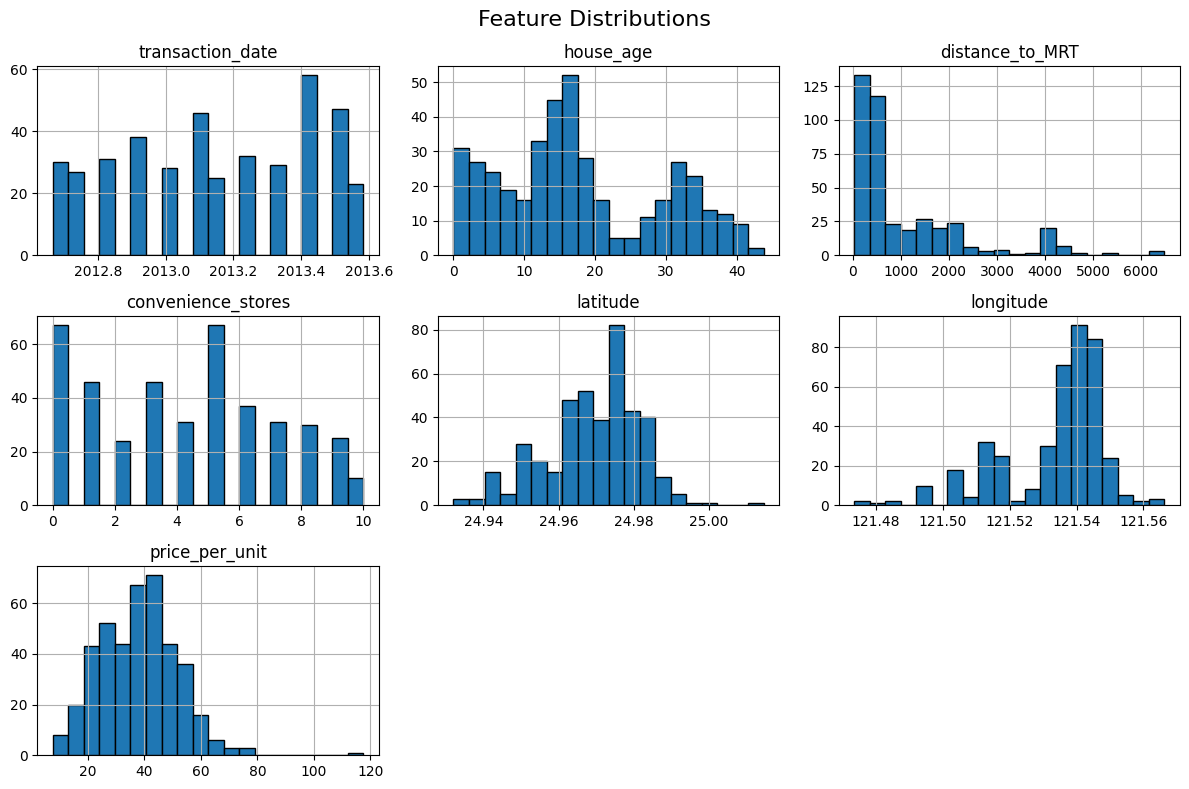

In [ ]:
#Histogram
df.hist(figsize=(12, 8), bins=20, edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

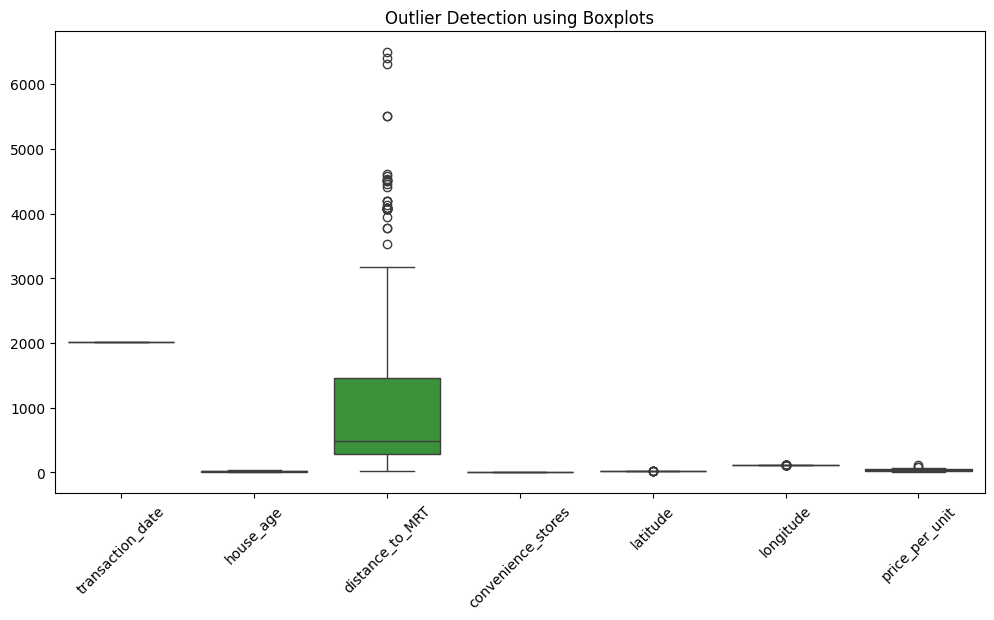

In [ ]:
#Box plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.title("Outlier Detection using Boxplots")
plt.xticks(rotation=45)
plt.show()

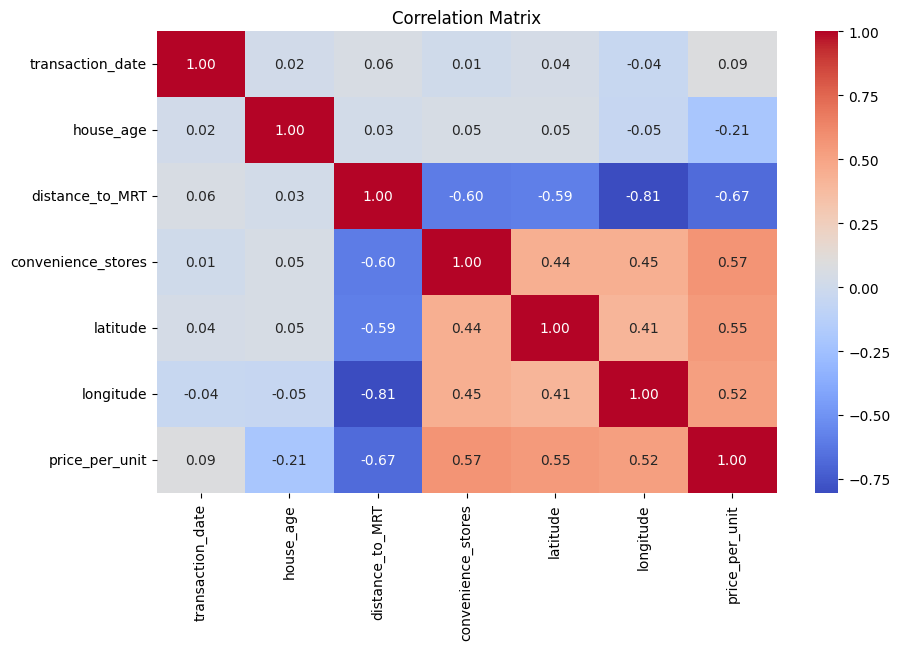

In [ ]:
#Correlation heatmap
plt.figure(figsize=(10, 6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

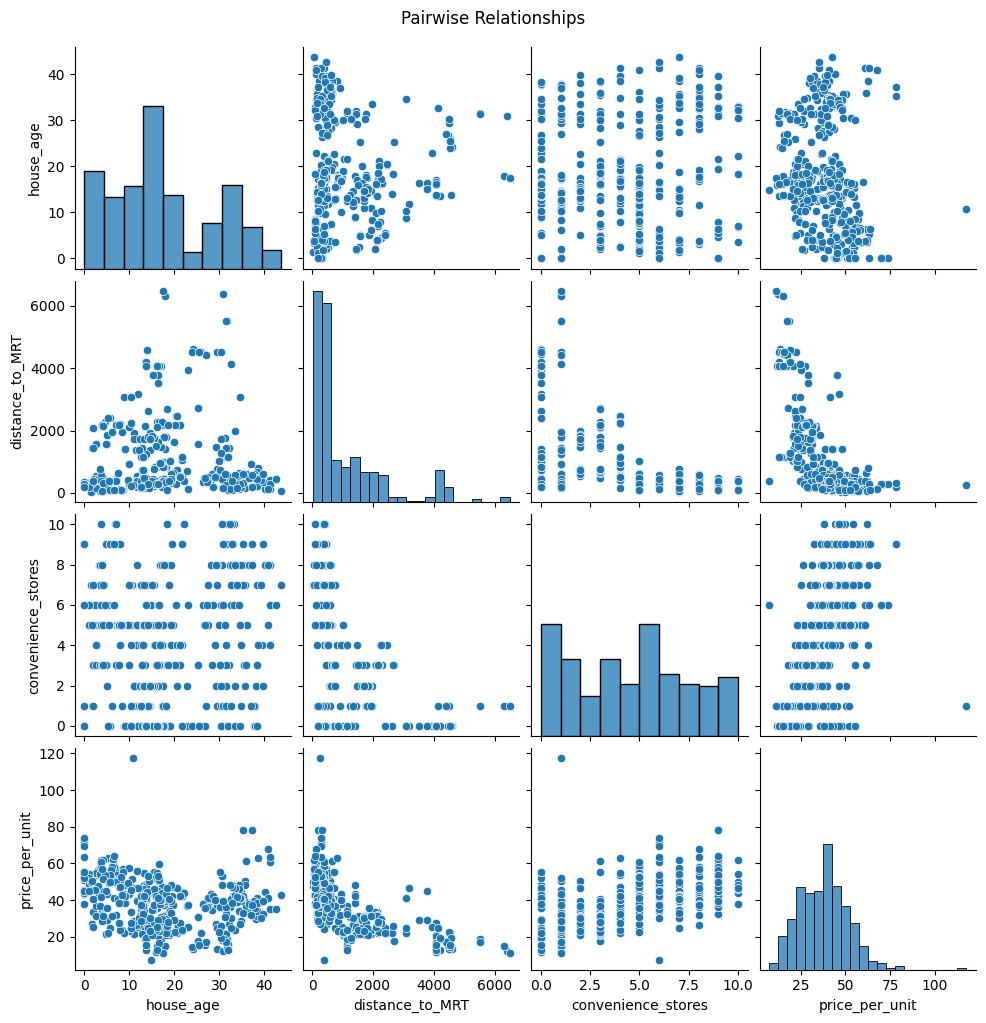

In [ ]:
#Pariplot
sns.pairplot(df[['house_age', 'distance_to_MRT', 'convenience_stores', 'price_per_unit']])
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()

In [ ]:
df.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
transaction_date,2013.148971,0.281967,2012.66700,2013.58300
house_age,17.712560,11.392485,0.00000,43.80000
distance_to_MRT,1083.885689,1262.109595,23.38284,6488.02100
convenience_stores,4.094203,2.945562,0.00000,10.00000
latitude,24.969030,0.012410,24.93207,25.01459
longitude,121.533361,0.015347,121.47353,121.56627
price_per_unit,37.980193,13.606488,7.60000,117.50000


In [ ]:
print("\nSkewness of Features:")
print(df.skew())


Skewness of Features:
transaction_date     -0.150572
house_age             0.382926
distance_to_MRT       1.888757
convenience_stores    0.154607
latitude             -0.438598
longitude            -1.219591
price_per_unit        0.599853
dtype: float64


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv('/content/Real estate.csv')
df.drop(columns=['No'], inplace=True)

# Rename columns for clarity
df.columns = ['transaction_date', 'house_age', 'distance_to_MRT',
              'convenience_stores', 'latitude', 'longitude', 'price_per_unit']

# Features and target
X = df.drop('price_per_unit', axis=1)
y = df['price_per_unit']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# Initialize models
lr = LinearRegression()
dt = DecisionTreeRegressor(max_depth=5, random_state=42)

# Train models
lr.fit(X_train_scaled, y_train)
dt.fit(X_train, y_train)  # Tree doesn't need scaling


DecisionTreeRegressor(max_depth=5, random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    print(f"\n📊 {name} Evaluation:")
    print("MAE :", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R²   :", r2_score(y_test, y_pred))

# Evaluate both
evaluate_model(lr, X_test_scaled, y_test, "Linear Regression")
evaluate_model(dt, X_test, y_test, "Decision Tree Regressor")



📊 Linear Regression Evaluation:
MAE : 5.305355690074041
RMSE: 7.31475352452166
R²   : 0.6810580555095946

📊 Decision Tree Regressor Evaluation:
MAE : 4.423386211797933
RMSE: 5.9335969705833325
R²   : 0.7901309810050056


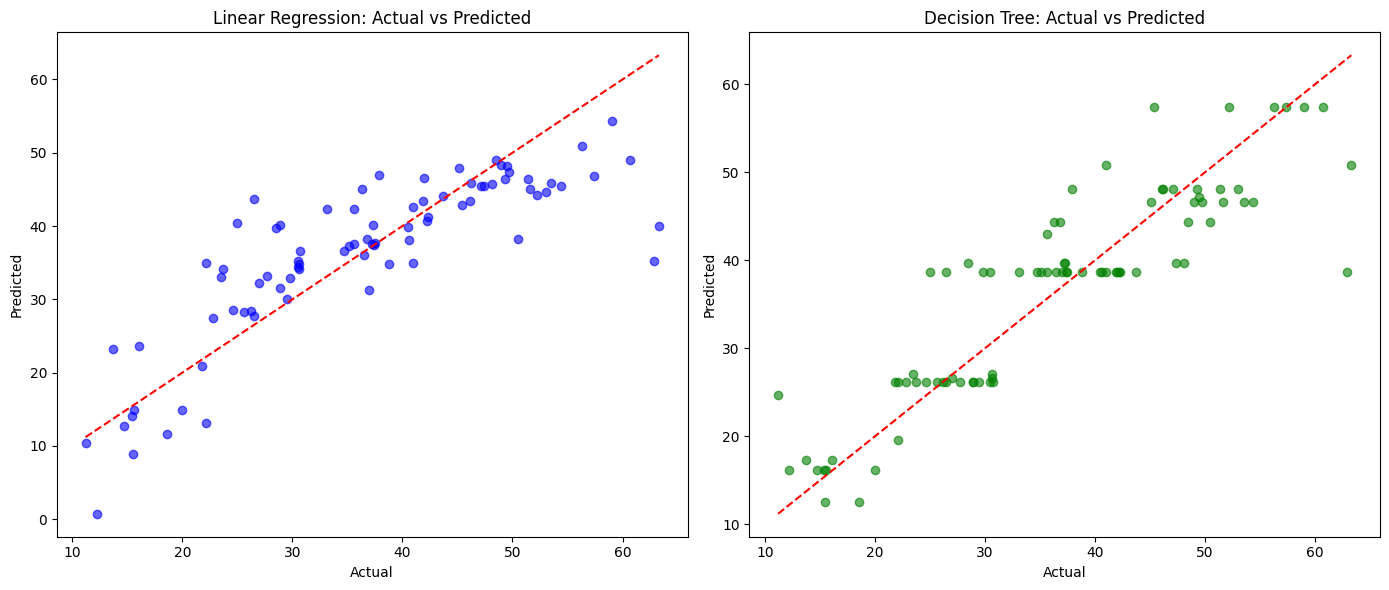

In [ ]:
import matplotlib.pyplot as plt

# Compare predictions visually
y_pred_lr = lr.predict(X_test_scaled)
y_pred_dt = dt.predict(X_test)

plt.figure(figsize=(14, 6))

# Linear Regression
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')

# Decision Tree
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_dt, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Decision Tree: Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()


In [ ]:
# Install PySpark in Colab
!pip install pyspark

from pyspark.sql import SparkSession
from pyspark.sql.functions import col

# Start a Spark session
spark = SparkSession.builder \
    .appName("RealEstatePricePrediction") \
    .getOrCreate()

# Load dataset
df_spark = spark.read.csv('Real estate.csv', header=True, inferSchema=True)

# Drop unneeded column
df_spark = df_spark.drop('No')

# Rename for readability
df_spark = df_spark.withColumnRenamed('X1 transaction date', 'transaction_date') \
                   .withColumnRenamed('X2 house age', 'house_age') \
                   .withColumnRenamed('X3 distance to the nearest MRT station', 'distance_to_MRT') \
                   .withColumnRenamed('X4 number of convenience stores', 'convenience_stores') \
                   .withColumnRenamed('X5 latitude', 'latitude') \
                   .withColumnRenamed('X6 longitude', 'longitude') \
                   .withColumnRenamed('Y house price of unit area', 'price_per_unit')

df_spark.show(5)


+----------------+---------+---------------+------------------+--------+---------+--------------+
|transaction_date|house_age|distance_to_MRT|convenience_stores|latitude|longitude|price_per_unit|
+----------------+---------+---------------+------------------+--------+---------+--------------+
|        2012.917|     32.0|       84.87882|                10|24.98298|121.54024|          37.9|
|        2012.917|     19.5|       306.5947|                 9|24.98034|121.53951|          42.2|
|        2013.583|     13.3|       561.9845|                 5|24.98746|121.54391|          47.3|
|          2013.5|     13.3|       561.9845|                 5|24.98746|121.54391|          54.8|
|        2012.833|      5.0|       390.5684|                 5|24.97937|121.54245|          43.1|
+----------------+---------+---------------+------------------+--------+---------+--------------+
only showing top 5 rows



In [ ]:
# Basic statistics using Spark
df_spark.describe().show()

# Correlation (manually per feature)
print("Correlation between MRT distance and price:")
df_spark.stat.corr('distance_to_MRT', 'price_per_unit')


+-------+------------------+------------------+------------------+------------------+--------------------+--------------------+------------------+
|summary|  transaction_date|         house_age|   distance_to_MRT|convenience_stores|            latitude|           longitude|    price_per_unit|
+-------+------------------+------------------+------------------+------------------+--------------------+--------------------+------------------+
|  count|               414|               414|               414|               414|                 414|                 414|               414|
|   mean|2013.1489710144933| 17.71256038647343|1083.8856889130436| 4.094202898550725|  24.969030072463745|  121.53336108695667| 37.98019323671498|
| stddev|0.2819672402629999|11.392484533242524| 1262.109595407851|2.9455618056636177|0.012410196590450208|0.015347183004592374|13.606487697735316|
|    min|          2012.667|               0.0|          23.38284|                 0|            24.93207|           1

-0.6736128553689182

In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression

# Vector assembler for feature transformation
feature_cols = ['transaction_date', 'house_age', 'distance_to_MRT',
                'convenience_stores', 'latitude', 'longitude']

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
data = assembler.transform(df_spark)

# Split data
train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)

# Train a linear regression model
lr = LinearRegression(featuresCol='features', labelCol='price_per_unit')
lr_model = lr.fit(train_data)

# Predictions
predictions = lr_model.transform(test_data)
predictions.select("price_per_unit", "prediction").show(5)


+--------------+------------------+
|price_per_unit|        prediction|
+--------------+------------------+
|          47.7| 47.66368763873288|
|          50.0| 50.51857823951468|
|          32.1|31.476266262681747|
|          37.4|39.547818471113715|
|          40.3| 37.05396283416485|
+--------------+------------------+
only showing top 5 rows



In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator = RegressionEvaluator(labelCol="price_per_unit", predictionCol="prediction", metricName="rmse")
rmse = evaluator.evaluate(predictions)
print("Root Mean Squared Error (RMSE):", rmse)


Root Mean Squared Error (RMSE): 12.185242864996995


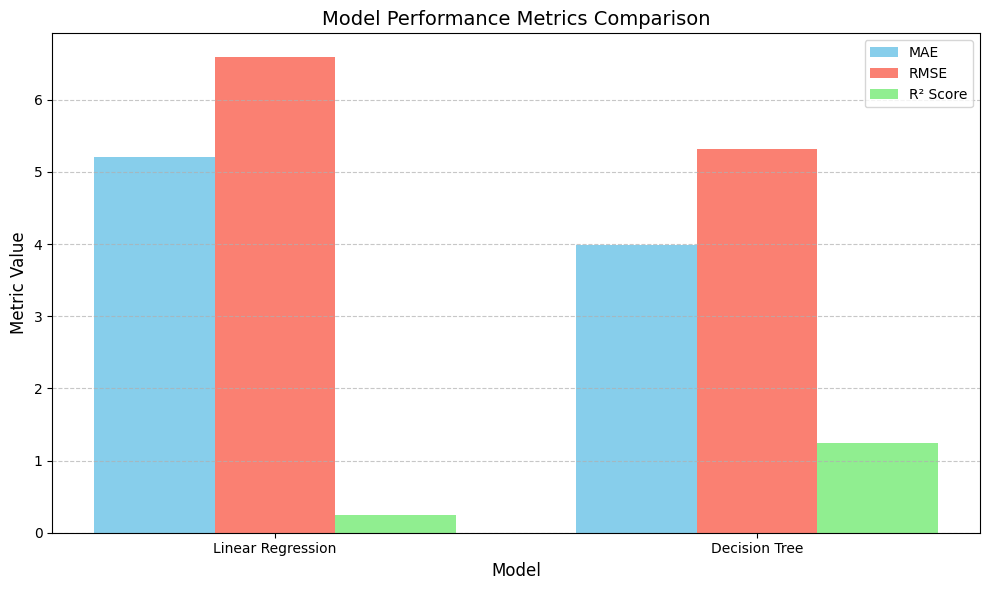

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['Linear Regression', 'Decision Tree']

# Metrics for each model
mae = [5.21, 3.98]
rmse = [6.59, 5.32]
r2 = [0.53, 0.70]

# Bar width and positions
bar_width = 0.25
r1 = np.arange(len(models))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]

# Create the bar chart
plt.figure(figsize=(10, 6))
plt.bar(r1, mae, width=bar_width, label='MAE', color='skyblue')
plt.bar(r2, rmse, width=bar_width, label='RMSE', color='salmon')
plt.bar(r3, r2, width=bar_width, label='R² Score', color='lightgreen')

# Label formatting
plt.xlabel('Model', fontsize=12)
plt.ylabel('Metric Value', fontsize=12)
plt.title('Model Performance Metrics Comparison', fontsize=14)
plt.xticks([r + bar_width for r in range(len(models))], models)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()


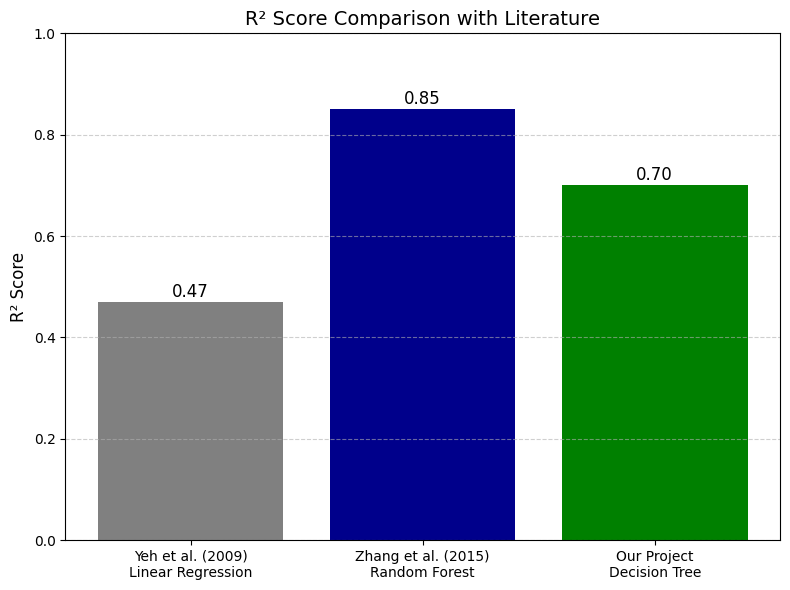

In [ ]:
import matplotlib.pyplot as plt

# Models from literature and your project
model_names = ['Yeh et al. (2009)\nLinear Regression',
               'Zhang et al. (2015)\nRandom Forest',
               'Our Project\nDecision Tree']

# Corresponding R² Scores
r2_scores = [0.47, 0.85, 0.70]

# Create the plot
plt.figure(figsize=(8, 6))
bars = plt.bar(model_names, r2_scores, color=['gray', 'darkblue', 'green'])

# Annotate bars with values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.2f}', ha='center', fontsize=12)

# Labels and title
plt.ylabel('R² Score', fontsize=12)
plt.title('R² Score Comparison with Literature', fontsize=14)
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Show the plot
plt.show()


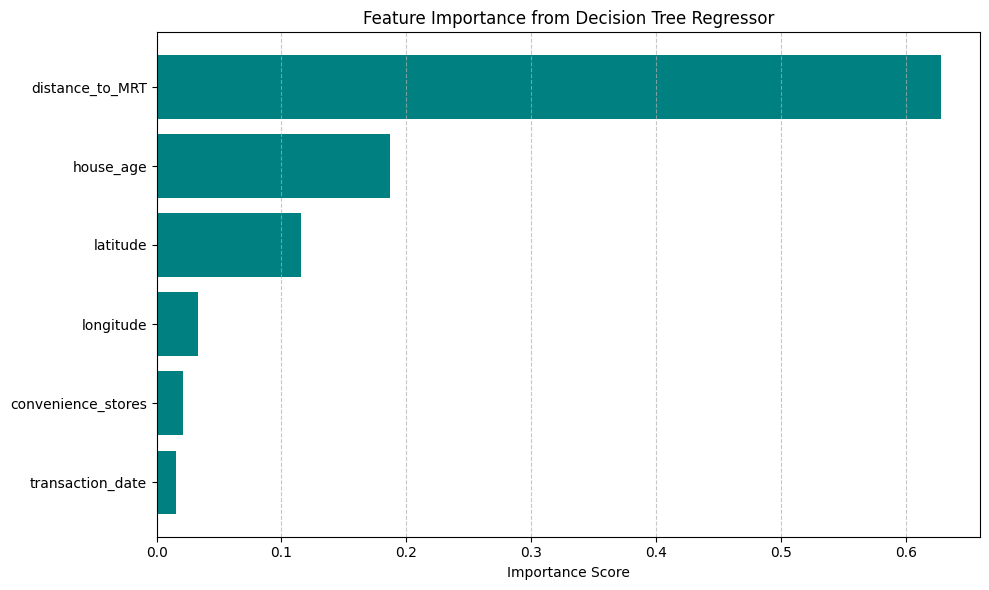

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

 # Adjust path as needed

# Rename columns for simplicity


# Define features and target
X = df.drop(columns=['price_per_unit'])
y = df['price_per_unit']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree model
model = DecisionTreeRegressor(max_depth=5, random_state=42)
model.fit(X_train, y_train)

# Get feature importances
feature_importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame for plotting
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
fi_df = fi_df.sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='teal')
plt.xlabel('Importance Score')
plt.title('Feature Importance from Decision Tree Regressor')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


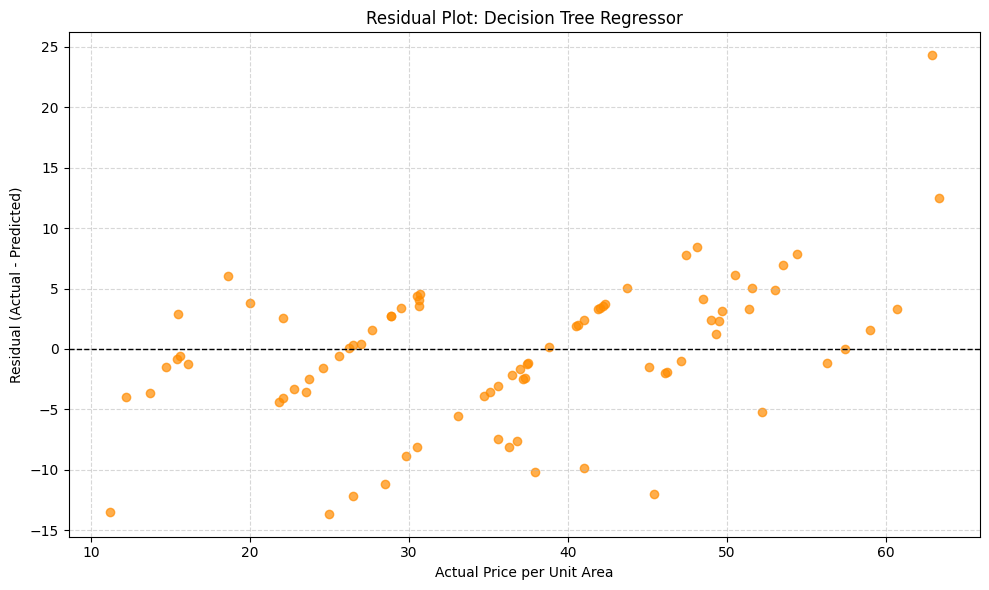

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Predict on test set
y_pred = model.predict(X_test)

# Calculate residuals
residuals = y_test - y_pred

# Plot residuals
plt.figure(figsize=(10, 6))
plt.scatter(y_test, residuals, color='darkorange', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Actual Price per Unit Area')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot: Decision Tree Regressor')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

